<a href="https://colab.research.google.com/github/Roberto50p/Notebook_fraude_financiero/blob/main/EVALUACI%C3%93N_2_DE_MINER%C3%8DA_DE_DATOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EVALUACIÓN DE MINERÍA DE DATOS**
Información del Grupo

Nombre o Número de Grupo: 7
Sección: 004D

Fecha de Entrega: 28-05-2026

Integrantes del Grupo

**Estudiante 1**
Nombre:Felipe
Apellido:Cayún
Correo institucional: Fe.cayun@duocuc.cl

**Estudiante 2**
Nombre:Roberto
Apellido:Bustos
Correo institucional: Rob.bustos@duocuc.cl


**# Tema del Proyecto**
Detección de Fraude Financiero mediante Machine Learning

# **Descripción del Proyecto**

El fraude financiero representa uno de los principales problemas para bancos, plataformas de pago y empresas fintech, debido a las pérdidas económicas y riesgos de seguridad que generan las transacciones fraudulentas.

El presente proyecto tiene como objetivo desarrollar un modelo de Machine Learning capaz de detectar transacciones sospechosas utilizando variables relacionadas con el comportamiento financiero de los usuarios.

Para ello, se trabajó con un dataset de transacciones financieras que incluye variables numéricas y categóricas relacionadas con:

montos de transacción,
dispositivos utilizados,
métodos de pago,
comportamiento del cliente,
ubicación,
uso de VPN,
velocidad de transacciones,
entre otras.

El análisis realizado busca identificar patrones asociados al fraude financiero mediante técnicas de análisis exploratorio de datos, preprocesamiento y modelado predictivo.

Este modelo podría ser utilizado por instituciones financieras para:

detectar fraudes en tiempo real,
disminuir pérdidas económicas,
mejorar sistemas de seguridad,
automatizar procesos de validación de transacciones.

# **Introducción a la Metodología**

Para el desarrollo del proyecto se utilizó la metodología CRISP-DM (Cross Industry Standard Process for Data Mining), ampliamente utilizada en proyectos de minería de datos y Machine Learning.

Esta metodología permite estructurar el proyecto en distintas fases:

Comprensión del negocio
Comprensión de los datos
Preparación de los datos
Análisis exploratorio
Modelado
Evaluación
Conclusiones

# **Comprensión del Negocio**
El fraude financiero afecta directamente a empresas, bancos y clientes, generando pérdidas económicas, riesgos de seguridad y problemas de confianza en plataformas digitales.

El objetivo principal de este proyecto es desarrollar un modelo predictivo capaz de identificar transacciones fraudulentas utilizando Machine Learning.

La detección automática de fraude permite:

mejorar la seguridad financiera,
disminuir pérdidas monetarias,
agilizar procesos de validación,
reducir intervención manual.

Desde una perspectiva empresarial, este tipo de modelos puede apoyar la toma de decisiones relacionadas con:

aprobación de transacciones,
bloqueo preventivo,
monitoreo de operaciones sospechosas,
análisis de riesgo financiero.

# **Comprensión de los Datos**

Fuente del Dataset

El dataset utilizado corresponde a un conjunto de transacciones financieras relacionadas con fraude financiero.

El conjunto de datos contiene información sobre:

comportamiento de usuarios,
métodos de pago,
dispositivos,
montos,
ubicaciones,
patrones de actividad financiera.

# **Variables del Dataset**

El dataset contiene:

variables numéricas,
variables categóricas,
variables relacionadas con comportamiento financiero.
Variable Objetivo

La variable objetivo corresponde a:

label

Donde:

0 = transacción legítima
1 = transacción fraudulenta

# **Variables Predictoras**

**Algunas variables relevantes utilizadas fueron:**

transaction_amount
vpn_detected
is_new_device
distance_from_home_km
transaction_velocity_1h
high_risk_country
payment_method
device_type
customer_segment
Tipos de Datos

Durante el análisis se identificaron:

variables numéricas,
variables categóricas,
columnas de fecha y hora.

Esto fue importante debido a que los algoritmos de Machine Learning requieren principalmente datos numéricos para funcionar correctamente.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
sns.set(style="whitegrid")

In [ ]:
from google.colab import files
uploaded = files.upload()
for key in uploaded.keys():
    fileName = key
df = pd.read_csv(fileName)
print("Dataset cargado correctamente")

Saving enterprise_fraud_dataset.csv to enterprise_fraud_dataset.csv
Dataset cargado correctamente


La función **head()** permite visualizar las primeras filas del dataset.

Esto es importante porque:
ayuda a entender la estructura de los datos,
permite identificar columnas,
facilita detectar errores iniciales,
ayuda a comprender el tipo de información disponible.

In [ ]:
df.head()

,transaction_id,customer_id,merchant_id,timestamp,hour,day,weekday,is_weekend,is_night,customer_segment,...,transaction_velocity_7d,seconds_since_last_txn,avg_amount_30d,amount_deviation_ratio,merchant_ring_id,shared_device_count,customer_merchant_txn_count,label,fraud_type,financial_loss
0,TXN00036139,9802,1487,2025-01-22 14:02:41.154565663,14,22,2,0,0,regular,...,20,5.035833e+05,426.455356,0.9937,-1,0,4,0,legit,0.0
1,TXN00080533,9762,1412,2025-02-18 01:53:25.069276265,1,49,1,0,1,regular,...,16,1.607163e+06,298.932645,0.2719,-1,0,1,0,legit,0.0
2,TXN00104222,9230,1690,2025-03-04 00:29:01.950036691,0,63,1,0,1,regular,...,17,1.702030e+05,502.709227,0.6882,-1,2,1,0,legit,0.0
3,TXN00154470,6009,942,2025-04-02 21:41:53.035782236,21,92,2,0,0,regular,...,17,1.076657e+04,320.324984,0.8116,13,0,3,0,legit,0.0
4,TXN00079799,2818,715,2025-02-17 14:30:54.154685560,14,48,0,0,0,regular,...,14,2.087674e+06,183.407743,0.7762,13,1,4,0,legit,0.0


**La función shape permite conocer:**

cantidad de filas,
cantidad de columnas.
Esto ayuda a entender:
el tamaño del dataset, complejidad del análisis, posibles requerimientos computacionales.

print("Dimensiones del dataset:")
print(df.shape)

**df.info() permite:**

identificar tipos de datos,
detectar columnas categóricas,
verificar valores nulos,
comprender estructura del dataset.

Esto es importante porque los modelos de Machine Learning requieren principalmente variables numéricas.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   transaction_id               200000 non-null  object 
 1   customer_id                  200000 non-null  int64  
 2   merchant_id                  200000 non-null  int64  
 3   timestamp                    200000 non-null  object 
 4   hour                         200000 non-null  int64  
 5   day                          200000 non-null  int64  
 6   weekday                      200000 non-null  int64  
 7   is_weekend                   200000 non-null  int64  
 8   is_night                     200000 non-null  int64  
 9   customer_segment             200000 non-null  object 
 10  avg_spend_profile            200000 non-null  float64
 11  home_lat                     200000 non-null  float64
 12  home_lon                     200000 non-null  float64
 13 

# **Preparación de los** **Datos**

Durante la etapa de preparación de datos se realizaron distintos procesos orientados a mejorar la calidad y compatibilidad del dataset para el entrenamiento del modelo de Machine Learning. En primer lugar, se verificó la existencia de valores nulos y registros duplicados, ya que este tipo de inconsistencias puede afectar negativamente el rendimiento del modelo, generar sesgos o provocar errores durante el análisis.

Posteriormente, se eliminaron columnas consideradas irrelevantes o problemáticas, como identificadores únicos y variables de fecha, debido a que no aportaban valor predictivo y podían generar sobreajuste o incompatibilidades técnicas. Finalmente, se aplicó One Hot Encoding sobre las variables categóricas para transformar la información textual en datos numéricos, permitiendo así que el algoritmo Random Forest pudiera interpretar correctamente las variables del dataset.

**Los valores nulos** pueden afectar negativamente el rendimiento del modelo.
Problemas que generan:
errores en entrenamiento,
pérdida de información,
sesgos estadísticos,
disminución de precisión.

Verificar nulos permite decidir:
eliminar registros,
imputar datos,
mantener columnas.

In [ ]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
transaction_id                 0
customer_id                    0
merchant_id                    0
timestamp                      0
hour                           0
day                            0
weekday                        0
is_weekend                     0
is_night                       0
customer_segment               0
avg_spend_profile              0
home_lat                       0
home_lon                       0
past_fraud_history             0
credit_score                   0
account_age_days               0
merchant_category              0
merchant_risk_score            0
merchant_lat                   0
merchant_lon                   0
transaction_amount             0
txn_lat                        0
txn_lon                        0
distance_from_home_km          0
is_foreign                     0
high_risk_country              0
device_type                    0
channel                        0
is_new_device                  0
vpn_detected    

# **VERIFICAR DUPLICADOS**

Los registros duplicados pueden:

sesgar resultados,
provocar sobreajuste,
alterar métricas,
duplicar patrones artificialmente.

**Eliminar duplicados mejora:**

calidad de datos,
confiabilidad del modelo,
capacidad de generalización.


In [ ]:
columnas_eliminar = [
    'transaction_id',
    'customer_id',
    'device_id',
    'fraud_type',
    'timestamp',
    'financial_loss'
]
columnas_existentes = [
    col for col in columnas_eliminar
    if col in df.columns
]
df = df.drop(columns=columnas_existentes)

print("Columnas eliminadas:")
print(columnas_existentes)

Columnas eliminadas:
['transaction_id', 'customer_id', 'device_id', 'fraud_type', 'timestamp', 'financial_loss']


¿Por qué hicimos esto?

transaction_id

Es un identificador único sin valor predictivo.

customer_id

Puede generar sobreajuste debido a memorización de clientes.

device_id

Presenta alta cardinalidad y poca utilidad analítica.

fraud_type

Puede generar data leakage al contener información relacionada directamente con el fraude.

timestamp

Se encontraba en formato texto y generaba errores durante el entrenamiento.

Eliminar estas columnas:

reduce ruido,
mejora eficiencia,
evita sobreajuste,
optimiza rendimiento del modelo.

# **Análisis Exploratorio de Datos**

Distribución de Fraude

Se analizó la distribución de la variable objetivo para identificar posibles problemas de desbalance.

El análisis mostró diferencias entre:

transacciones legítimas,
transacciones fraudulentas.

Este análisis es importante debido a que el desbalance de clases puede afectar el rendimiento del modelo.

**DISTRIBUCIÓN DE FRAUDE**

Este gráfico permite visualizar:

cantidad de transacciones fraudulentas,
cantidad de transacciones legítimas.

Esto es importante porque:

ayuda a detectar desbalance de clases,
permite seleccionar métricas adecuadas,
influye directamente en el entrenamiento.

donde:

# **0 = transacción legítima**
# **1** = **transacción** **fraudulenta**

# **Análisis Exploratorio de Datos**

Se realizaron visualizaciones y análisis estadísticos para identificar patrones relacionados con el fraude financiero y comprender el comportamiento de las variables más relevantes del dataset.

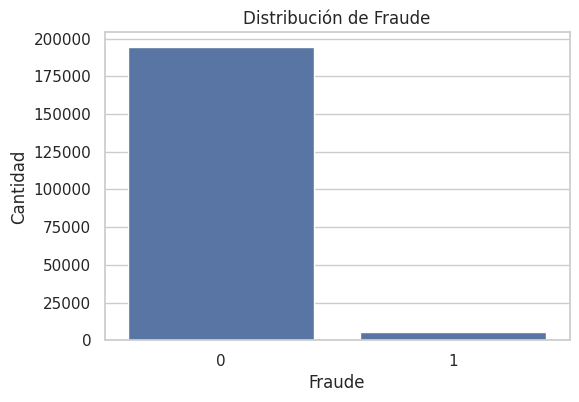

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title('Distribución de Fraude')
plt.xlabel('Fraude')
plt.ylabel('Cantidad')
plt.show()

# **ENCODING**

os modelos de Machine Learning no pueden trabajar directamente con variables categóricas en formato texto.

Por esta razón se aplicó **One Hot Encoding**.

Esta técnica:

transforma categorías en variables numéricas,
evita relaciones jerárquicas falsas,
mejora compatibilidad con algoritmos.

Se utilizó drop_first=True para:

reducir redundancia,
evitar multicolinealidad,
optimizar memoria RAM.

In [ ]:
categoricas = [
    col for col in [
        'payment_method',
        'channel',
        'device_type',
        'customer_segment',
        'merchant_category'
    ]
    if col in df.columns
]
df_encoded = pd.get_dummies(
    df,
    columns=categoricas,
    drop_first=True
)
print("Encoding aplicado correctamente")

Encoding aplicado correctamente


**DIVISIÓN TRAIN / TEST**

La división Train/Test permite:

entrenar el modelo,
evaluar rendimiento en datos nuevos,
evitar sobreajuste.

Se utilizó:

80% entrenamiento,
20% prueba.

stratify=y mantiene la proporción de fraude en ambos conjuntos.

In [ ]:
X = df_encoded.drop('label', axis=1)
y = df_encoded['label']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (160000, 52)
Datos de prueba: (40000, 52)


# **Modelado y Justificación**

El problema abordado corresponde a un problema de clasificación, debido a que el objetivo es predecir si una transacción es fraudulenta o legítima.

Para ello se utilizó Random Forest, algoritmo que presenta buen rendimiento en datasets tabulares y permite detectar relaciones complejas entre variables.

## **Random Forest**

Se eligió Random Forest debido a que:

funciona bien en datos tabulares,
detecta relaciones no lineales,
reduce overfitting,
maneja datasets complejos,
permite analizar importancia de variables.

class_weight='balanced'
ayuda a manejar el desbalance entre fraude y no fraude.

In [ ]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

modelo_rf.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


**PREDICCIONES**

Las predicciones permiten:

evaluar rendimiento,
comparar resultados reales,
calcular métricas.

In [ ]:
y_pred = modelo_rf.predict(X_test)

## **Evaluación del Modelo**

El rendimiento del modelo fue evaluado mediante métricas de clasificación como Accuracy, Precision, Recall y F1-score.

Además, se utilizó una matriz de confusión para analizar el comportamiento de las predicciones realizadas por el modelo.

**MÉTRICAS**

Mide porcentaje total de aciertos.

Precision

Indica cuántos fraudes detectados realmente eran fraude.

Recall

Mide cuántos fraudes reales fueron detectados.

En fraude financiero Recall es muy importante porque perder un fraude puede generar pérdidas económicas.

F1-score

Combina Precision y Recall.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9973
Precision: 0.9912023460410557
Recall: 0.9110512129380054
F1-score: 0.949438202247191


**MATRIZ DE CONFUSIÓN**

La matriz de confusión permite identificar:

verdaderos positivos,
verdaderos negativos,
falsos positivos,
falsos negativos.

Esto ayuda a entender:

errores del modelo,
capacidad de detección,
efectividad general.

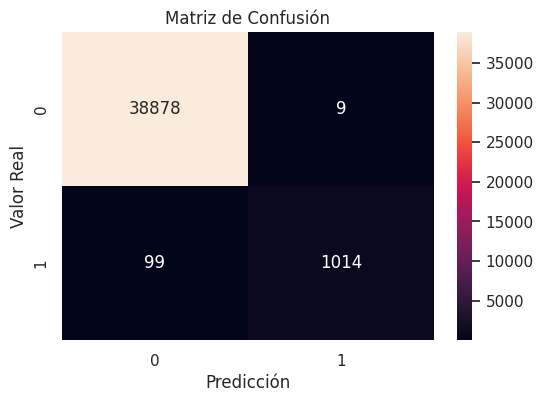

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

**FEATURE IMPORTANCE**

Feature Importance permite identificar:

variables más relevantes,
patrones importantes,
factores asociados al fraude.

Esto mejora:

interpretación del modelo,
comprensión del problema,
análisis financiero.



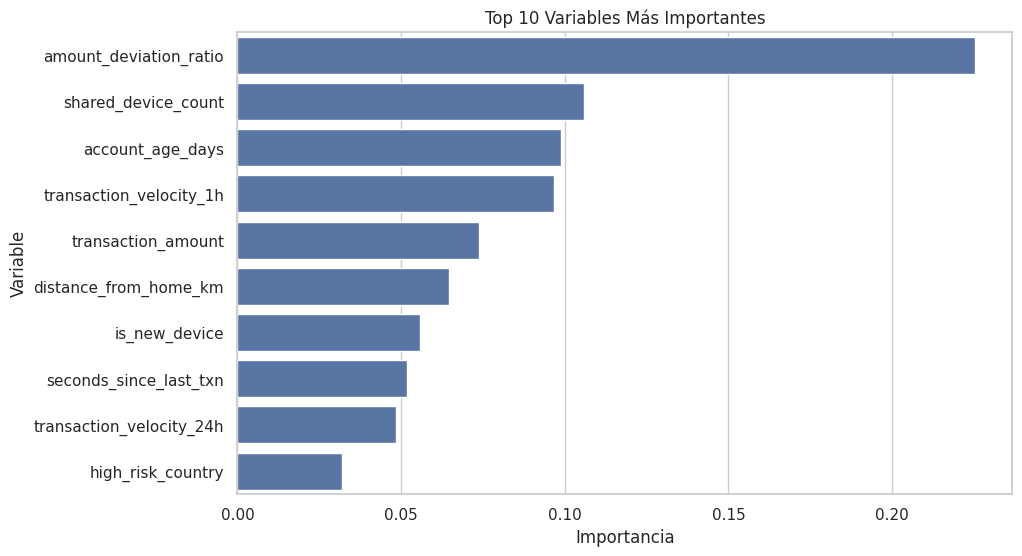

In [ ]:
importancias = modelo_rf.feature_importances_

feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
})
feature_importance = feature_importance.sort_values(
    by='Importancia',
    ascending=False
)
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importancia',
    y='Variable'
)
plt.title('Top 10 Variables Más Importantes')
plt.show()

# **Árbol de decisión**

In [ ]:
# Árbol de decisión con profundidad limitada para evitar sobreajuste
tree_model = DecisionTreeClassifier(
    max_depth=10,          # profundidad máxima (ajústala si quieres)
    random_state=42,
    class_weight='balanced'
)

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

# Métricas
print("=== ÁRBOL DE DECISIÓN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1-score:", f1_score(y_test, y_pred_tree))

=== ÁRBOL DE DECISIÓN ===
Accuracy: 0.991075
Precision: 0.7727272727272727
Recall: 0.9622641509433962
F1-score: 0.8571428571428571


In [ ]:
print("=== COMPARACIÓN FINAL ===")
print("Métrica     | Random Forest | Árbol Decisión")
print("------------------------------------------------")
print(f"Accuracy    | {accuracy_score(y_test, y_pred):.4f}      | {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"Precision   | {precision_score(y_test, y_pred):.4f}      | {precision_score(y_test, y_pred_tree):.4f}")
print(f"Recall      | {recall_score(y_test, y_pred):.4f}      | {recall_score(y_test, y_pred_tree):.4f}")
print(f"F1-score    | {f1_score(y_test, y_pred):.4f}      | {f1_score(y_test, y_pred_tree):.4f}")

=== COMPARACIÓN FINAL ===
Métrica     | Random Forest | Árbol Decisión
------------------------------------------------
Accuracy    | 0.9973      | 0.9911
Precision   | 0.9912      | 0.7727
Recall      | 0.9111      | 0.9623
F1-score    | 0.9494      | 0.8571


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Separar las características (X) de la variable objetivo (y)
# Asegúrate de usar el DataFrame que ya no tiene las columnas eliminadas (ej. 'fraud_type', 'customer_id')
X = df.drop(columns=['label'])
y = df['label']

# 2. Convertir las variables categóricas que queden a números (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# 3. Dividir en set de entrenamiento y prueba (80% entrenamiento, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Crear el modelo de Árbol de Decisión
# Usamos max_depth=4 para que el árbol no crezca infinito y lo puedas visualizar bien
arbol = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')

# 5. Entrenar el modelo
arbol.fit(X_train, y_train)

# 6. Evaluar qué tan bueno es
print("Precisión en el set de Entrenamiento:", arbol.score(X_train, y_train))
print("Precisión en el set de Test:", arbol.score(X_test, y_test))

Precisión en el set de Entrenamiento: 0.9583125
Precisión en el set de Test: 0.9568


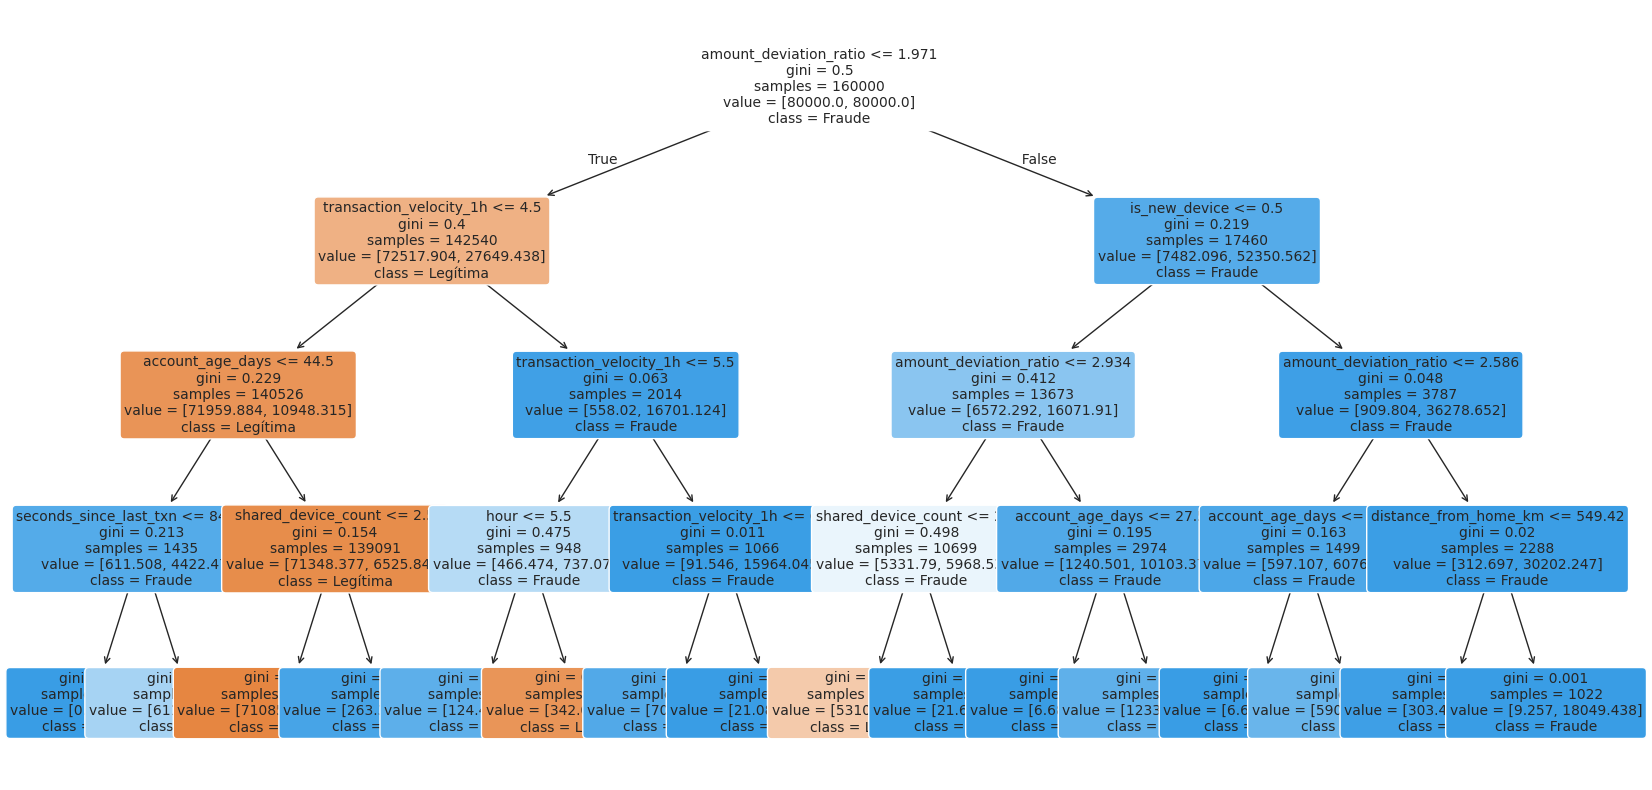

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(arbol,
          feature_names=X.columns,
          class_names=['Legítima', 'Fraude'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.show()

# **Conclusiones**

El proyecto permitió desarrollar un modelo de Machine Learning orientado a la detección de fraude financiero mediante Random Forest.

Los resultados obtenidos demostraron que variables relacionadas con comportamiento financiero, dispositivos y uso de VPN presentan relación con actividades fraudulentas.

Además, el proyecto permitió aplicar técnicas de análisis exploratorio, preprocesamiento y clasificación supervisada en un contexto real de minería de datos.